# Chapter 10 — Bayesian Methods

This notebook accompanies **Chapter 10** of *Inference in Statistical Modelling and Machine Learning*.

## Key ideas

A Bayesian model has three components: a **likelihood** (how data arise given parameters), a **prior** (initial beliefs about parameters), and the **posterior** obtained by Bayes' rule.  For simple models the posterior is available in closed form.  For more complex models we need **MCMC** — a recipe for drawing samples from a distribution we can only evaluate up to a normalising constant.

We work through both ideas using rainfall data from South-West England:

1. A **Binomial model** for the fraction of rainy days in the last two weeks of July — conjugate posterior, analytical.
2. A **Beta-Binomial model** to handle year-to-year variation (overdispersion) — non-conjugate, sampled via the **Metropolis algorithm** built from scratch.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist, binom, norm
from scipy.special import betaln, gammaln

rng = np.random.default_rng(42)

In [2]:
try:
    import google.colab
    DATA_PATH = "https://inferencebook.github.io/data/"
except ImportError:
    DATA_PATH = "../data/"


---
## The data

The dataset records daily precipitation (mm) in South-West England from 1931 to 2025, sourced from the HadSWEP series (Alexander & Jones 2001).  A day is classed as **rainy** if precipitation is ≥ 5 mm.

We focus on the **last two weeks of July** (days 18–31, 14 days per year) and ask: what fraction of those days are rainy?

> **Book link — §10.2.**  The chapter models the count of rainy days as Binomial$(14, p)$, where $p$ is the probability that any given day is rainy.

Years: 1931–2023  (93 years)
Total August days observed : 2884
Total very-rainy days      : 501
Empirical fraction rainy   : 0.174


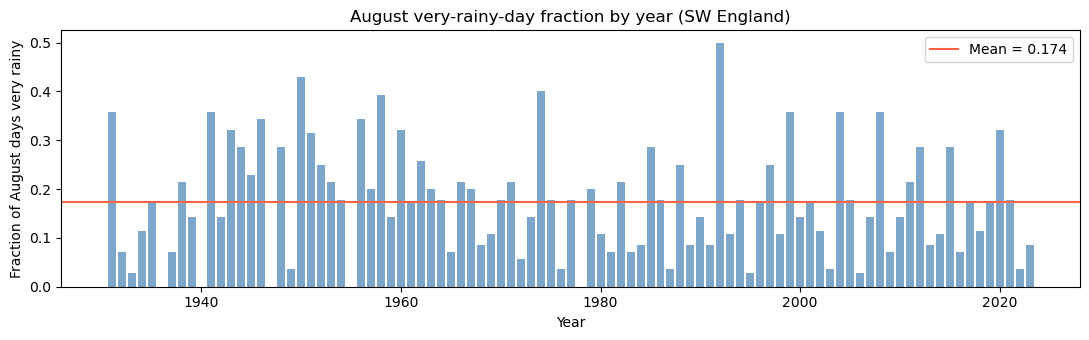

In [3]:
df = pd.read_csv(DATA_PATH + 'July_rain.csv')
display(df.head())

n_years  = len(df)
total_k  = int(df['rainy_days'].sum())
total_n  = n_years * 14          # 14 days per year

print(f"Years: {df['year'].min()}\u2013{df['year'].max()}  ({n_years} years)")
print(f"Total July days observed : {total_n}")
print(f"Total rainy days         : {total_k}")
print(f"Empirical fraction rainy : {total_k/total_n:.3f}")

# Bar chart of yearly rainy-day fractions
df['frac'] = df['rainy_days'] / 14
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(df['year'], df['frac'], color='steelblue', alpha=0.7, width=0.8)
ax.axhline(df['frac'].mean(), color='tomato', linewidth=1.5,
           label=f"Mean = {df['frac'].mean():.3f}")
ax.set_xlabel('Year')
ax.set_ylabel('Fraction of days rainy')
ax.set_title('Last two weeks of July — rainy-day fraction by year (SW England, \u22655 mm)')
ax.legend()
plt.tight_layout()
plt.show()

---
## The Binomial model and its conjugate posterior

Treat every day in the last two weeks of July in year $i$ as an independent Bernoulli trial with probability $p$ of being rainy.  The count of rainy days in year $i$ is
$$K_i \mid p \;\sim\; \text{Binomial}(14,\, p).$$

With a uniform prior $p \sim \text{Beta}(1,1)$, the conjugate posterior is
$$p \mid \text{data} \;\sim\; \text{Beta}(1 + K,\; 1 + N - K),$$
where $K$ is the total number of rainy days across all years and $N = 14n$ is the total number of days observed.

> **Book link — §10.2–10.3.**  The MAP estimate equals the MLE $\hat p = K/N$.  The 95% credible interval is the 2.5th–97.5th percentile of this Beta distribution.

MLE / MAP  : 0.1361
Posterior mean : 0.1366
95% credible interval: [0.1187, 0.1556]


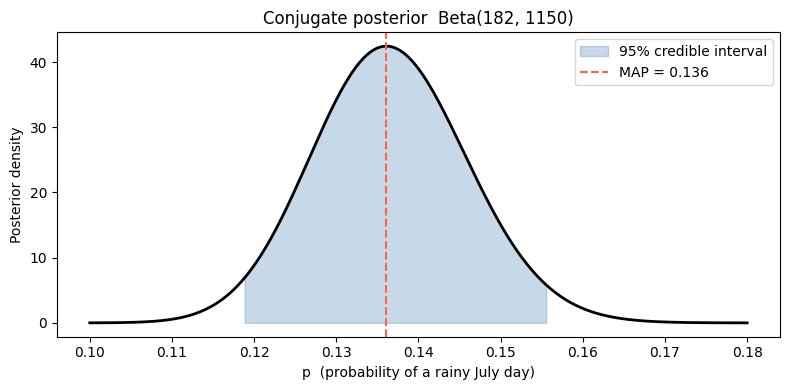

In [13]:
# Conjugate posterior: Beta(1+K, 1+N-K)
a_post = 1 + total_k
b_post = 1 + total_n - total_k

p_map  = total_k / total_n
p_mean = a_post / (a_post + b_post)
ci_lo, ci_hi = beta_dist.ppf([0.025, 0.975], a_post, b_post)

print(f"MLE / MAP  : {p_map:.4f}")
print(f"Posterior mean : {p_mean:.4f}")
print(f"95% credible interval: [{ci_lo:.4f}, {ci_hi:.4f}]")

p_grid = np.linspace(0.10, 0.18, 400)
pdf    = beta_dist.pdf(p_grid, a_post, b_post)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p_grid, pdf, 'k', linewidth=2)
ax.fill_between(p_grid, pdf,
                where=(p_grid >= ci_lo) & (p_grid <= ci_hi),
                alpha=0.3, color='steelblue', label='95% credible interval')
ax.axvline(p_map, color='tomato', linestyle='--', label=f'MAP = {p_map:.3f}')
ax.set_xlabel('p  (probability of a rainy July day)')
ax.set_ylabel('Posterior density')
ax.set_title(f'Conjugate posterior  Beta({a_post}, {b_post})')
ax.legend()
plt.tight_layout()
plt.show()

---
## Posterior predictive check — is the Binomial model adequate?

A **posterior predictive check** asks: if the model is correct, would data like ours look plausible?

We choose a **test statistic** $T$ that captures something important about the data — here, the standard deviation of the yearly rainy-day fractions, which measures year-to-year variability.  We then compare the observed value $T(\mathbf{k})$ with the distribution of $T$ under the model.

**Procedure:**

1. Draw $p^* \sim \text{Beta}(1+K, 1+N-K)$ from the posterior.
2. Using $p^*$, simulate a synthetic dataset: draw $\tilde{K}_i \sim \text{Binomial}(14, p^*)$ for each of the $n$ years.
3. Compute $T(\tilde{\mathbf{k}}) = \text{std}(\tilde{K}_i / 14)$ for this synthetic dataset.
4. Repeat steps 1–3 many times to build up the **posterior predictive distribution** of $T$.

The **Bayesian p-value** is the fraction of synthetic datasets whose test statistic is at least as extreme as the observed one:
$$p_B = \Pr\!\left(T(\tilde{\mathbf{K}}) \geq T(\mathbf{k})\right),$$
where the probability is taken over both the posterior draw of $p^*$ and the simulated data.  A value close to 0 means the observed statistic is larger than almost all synthetic ones — the model systematically underproduces the variability we see.

> **Book link — §10.3.**  A Bayesian p-value well below 0.01 or above 0.99 indicates model misfit.

Observed std of yearly fractions  : 0.1159
Posterior predictive mean std      : 0.0910
Bayesian p-value (P(sim ≥ obs))    : 0.0008


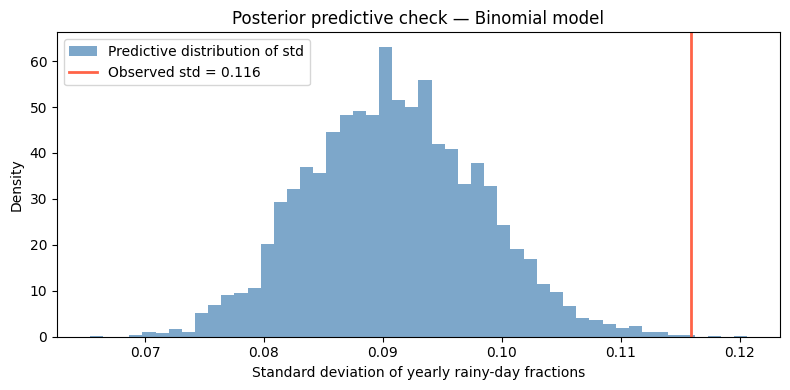


The observed std lies far to the right of the predictive distribution.
The Binomial model cannot account for the year-to-year variation — overdispersion.


In [14]:
n_sim    = 4000
ns_year  = np.full(n_years, 14)   # 14 days per year (constant across years)

# Step 1: draw n_sim values of p from the posterior
p_samp = rng.beta(a_post, b_post, size=n_sim)

# Steps 2-3: for each posterior draw, simulate a full synthetic dataset and
# compute the test statistic T = std of yearly rainy-day fractions
sim_stds = np.empty(n_sim)
for i, pi in enumerate(p_samp):
    k_syn        = rng.binomial(ns_year, pi)   # synthetic rainy-day counts per year
    sim_stds[i]  = np.std(k_syn / ns_year)     # T for this synthetic dataset

# Observed test statistic
obs_std = np.std(df['frac'].values)

# Bayesian p-value: fraction of synthetic T values >= observed T
bayes_p = np.mean(sim_stds >= obs_std)

print(f"Observed std of yearly fractions  : {obs_std:.4f}")
print(f"Posterior predictive mean std      : {sim_stds.mean():.4f}")
print(f"Bayesian p-value P(T_sim ≥ T_obs) : {bayes_p:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sim_stds, bins=50, density=True, color='steelblue', alpha=0.7,
        label='Predictive distribution of T')
ax.axvline(obs_std, color='tomato', linewidth=2, label=f'Observed T = {obs_std:.3f}')
ax.set_xlabel('std of yearly rainy-day fractions  (test statistic T)')
ax.set_ylabel('Density')
ax.set_title('Posterior predictive check — Binomial model')
ax.legend()
plt.tight_layout()
plt.show()

print()
print("The observed std lies far to the right of the predictive distribution.")
print("The Binomial model cannot account for the year-to-year variation — overdispersion.")

---
## The Beta-Binomial model

We extend the model to allow the probability of a rainy day to **vary by year**.  Each year $i$ gets its own $P_i \sim \text{Beta}(\alpha, \beta)$, and the rainy-day count in that year is $K_i \mid P_i \sim \text{Binomial}(n_i, P_i)$.

Marginalising over $P_i$ gives the **Beta-Binomial** distribution:
$$p(k_i \mid \alpha, \beta, n_i) = \binom{n_i}{k_i} \frac{B(\alpha + k_i,\; \beta + n_i - k_i)}{B(\alpha, \beta)},$$

where $B(a,b) = \Gamma(a)\Gamma(b)/\Gamma(a+b)$ is the Beta function.  The parameters $(\alpha, \beta)$ are now the unknowns — and there is no conjugate prior that makes the posterior tractable.  We need **MCMC**.

> **Book link — §10.4–10.5.**  We work in the transformed space $(\log\alpha, \log\beta)$ so the sampler can freely explore the positive quadrant.

In [15]:
ks = df['rainy_days'].values.astype(float)
ns = np.full(n_years, 14.0)

def log_beta_binom_lik(log_alpha, log_beta):
    """Log-likelihood of the Beta-Binomial model summed over all years."""
    a = np.exp(log_alpha)
    b = np.exp(log_beta)
    if a <= 0 or b <= 0:
        return -np.inf
    # log p(k_i | alpha, beta, n_i)  summed over years
    ll = np.sum(
        betaln(a + ks, b + ns - ks) - betaln(a, b)
        + gammaln(ns + 1) - gammaln(ks + 1) - gammaln(ns - ks + 1)
    )
    return ll

def log_prior(log_alpha, log_beta):
    """HalfNormal(50) prior on alpha and beta, expressed in log space."""
    a, b = np.exp(log_alpha), np.exp(log_beta)
    lp = (-0.5 * (a/50)**2 - 0.5 * (b/50)**2
          + log_alpha + log_beta)   # Jacobian of the log transform
    return lp

def log_posterior(log_alpha, log_beta):
    return log_beta_binom_lik(log_alpha, log_beta) + log_prior(log_alpha, log_beta)

# Quick sanity check near plausible values (alpha≈1.7, beta≈9.3 => mean p≈0.155)
la0, lb0 = np.log(1.7), np.log(9.3)
print(f"log-posterior at (log α={la0:.2f}, log β={lb0:.2f}): {log_posterior(la0, lb0):.2f}")

log-posterior at (log α=0.53, log β=2.23): -168.10


---
## The Metropolis algorithm

The **Metropolis algorithm** (Box 10.4) builds a Markov chain whose stationary distribution is the target posterior.  Starting from a current point $\boldsymbol{\theta}^{(t)}$:

1. **Propose** $\boldsymbol{\theta}^* = \boldsymbol{\theta}^{(t)} + \epsilon$, where $\epsilon \sim N(\mathbf{0}, b^2 I)$.
2. **Compute** acceptance ratio $r = \exp\!\left[\log\pi(\boldsymbol{\theta}^*) - \log\pi(\boldsymbol{\theta}^{(t)})\right]$.
3. **Accept** $\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^*$ with probability $\min(1, r)$; otherwise stay at $\boldsymbol{\theta}^{(t)}$.

The step size $b$ controls the trade-off: too small → chain moves slowly (high autocorrelation); too large → most proposals are rejected (chain stays put).  A useful rule of thumb is to aim for **about half** of proposed steps being accepted.

> **Book link — §10.5, Figure 10.5.**  Trace plots for three step sizes illustrate how $b$ governs mixing.

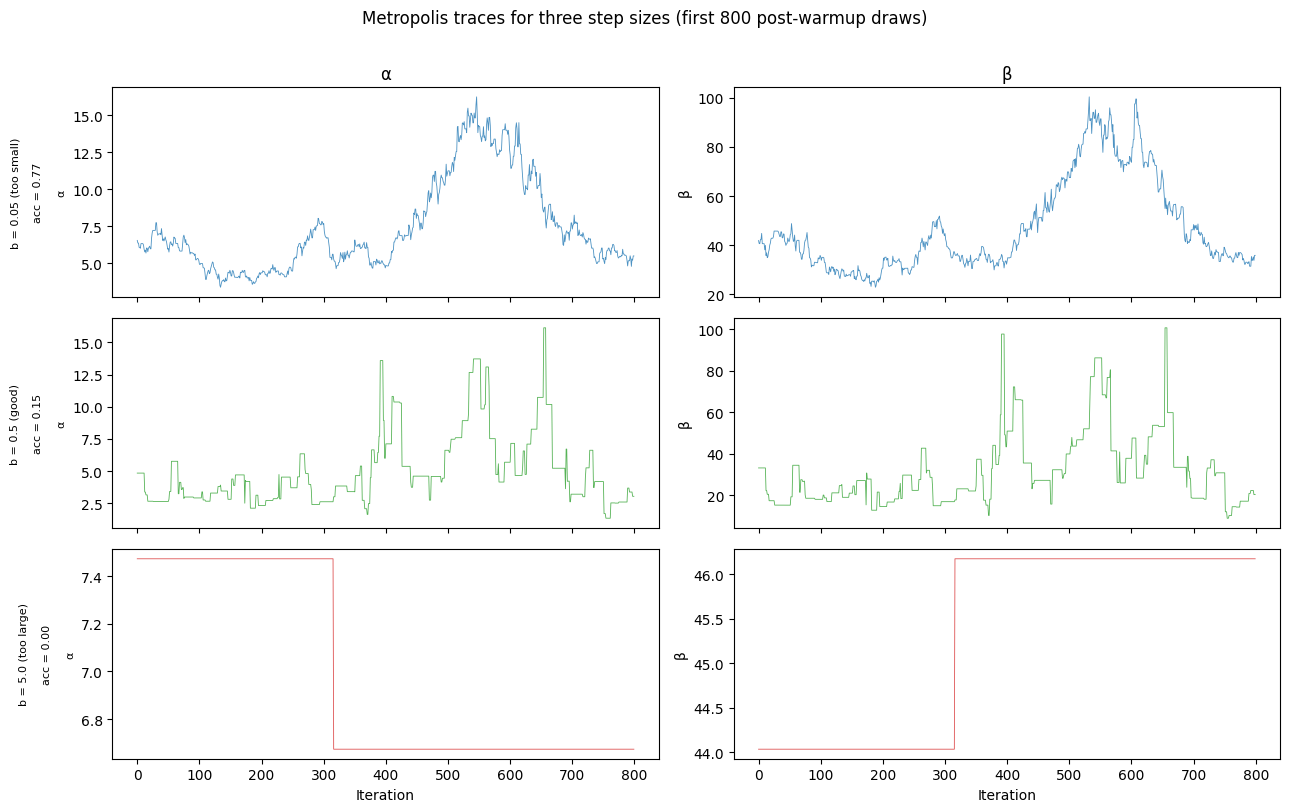

In [16]:
def metropolis(log_post, theta0, n_iter, step, rng):
    """Random-walk Metropolis sampler.  Returns (samples, acceptance_rate)."""
    d       = len(theta0)
    samples = np.empty((n_iter, d))
    current = np.array(theta0, dtype=float)
    lp_cur  = log_post(*current)
    n_acc   = 0

    for t in range(n_iter):
        proposal = current + rng.normal(0, step, size=d)
        lp_prop  = log_post(*proposal)
        if np.log(rng.uniform()) < lp_prop - lp_cur:
            current = proposal
            lp_cur  = lp_prop
            n_acc  += 1
        samples[t] = current

    return samples, n_acc / n_iter


theta0   = [np.log(1.5), np.log(9.0)]   # starting point
n_warmup = 2000
n_draw   = 5000
step_sizes = [0.05, 0.5, 5.0]
labels     = ['b = 0.05 (too small)', 'b = 0.5 (good)', 'b = 5.0 (too large)']
colors     = ['C0', 'C2', 'C3']

fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharex='col')

chain_good = None
for row, (b, lbl, col) in enumerate(zip(step_sizes, labels, colors)):
    samp, acc = metropolis(log_posterior, theta0,
                           n_warmup + n_draw, b, rng)
    samp_draw = samp[n_warmup:]
    if b == 0.5:
        chain_good = samp_draw

    for j, (pname, transform) in enumerate(
            [('log α', np.exp), ('log β', np.exp)]):
        ax = axes[row, j]
        vals = transform(samp_draw[:, j]) if j == 0 else transform(samp_draw[:, j])
        ax.plot(vals[:800], linewidth=0.6, color=col, alpha=0.8)
        fname = 'α' if j == 0 else 'β'
        ax.set_ylabel(fname, fontsize=10)
        if row == 0:
            ax.set_title(fname)

    axes[row, 0].set_ylabel(f'{lbl}\n\nacc = {acc:.2f}\n\nα', fontsize=8)

axes[-1, 0].set_xlabel('Iteration')
axes[-1, 1].set_xlabel('Iteration')
plt.suptitle('Metropolis traces for three step sizes (first 800 post-warmup draws)',
             y=1.01)
plt.tight_layout()
plt.show()

---
## Convergence diagnostics: $\hat{R}$ and $n_{\text{eff}}$

We run **multiple independent chains** and check two statistics.

**$\hat{R}$ (potential scale reduction factor, §10.5).**  For $M$ chains each of length $L$:
$$\hat{R} = \sqrt{\frac{\hat{V}}{W}}, \qquad
\hat{V} = \frac{L-1}{L}W + \frac{B}{L}, \qquad
W = \frac{1}{M}\sum_m s_m^2, \qquad
B = \frac{L}{M-1}\sum_m (\bar\theta_m - \bar\theta)^2.$$
$\hat{R} \approx 1$ means the chains agree — a necessary (not sufficient) condition for convergence.

**$n_{\text{eff}}$ (effective sample size).**  High autocorrelation means successive samples carry less new information.  If $\hat\rho_t$ is the lag-$t$ autocorrelation, $n_{\text{eff}} \approx ML / (1 + 2\sum_t \hat\rho_t)$.

> **Book link — §10.5.**  The rule of thumb is $\hat{R} < 1.01$ and $n_{\text{eff}} > 400$ before reporting posterior summaries.

log α:  R̂ = 1.0051,  n_eff ≈ 268
log β:  R̂ = 1.0038,  n_eff ≈ 272


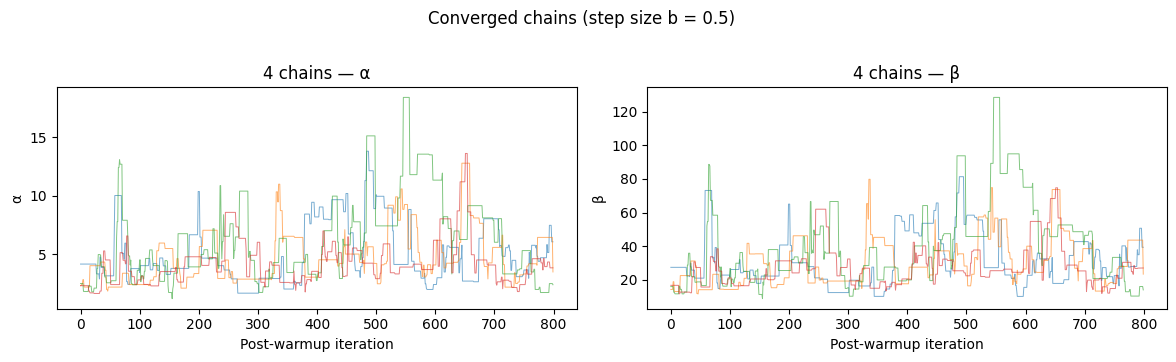

In [17]:
def r_hat(chains):
    """chains: array (M, L) — M chains, L samples each."""
    M, L  = chains.shape
    chain_means = chains.mean(axis=1)          # (M,)
    grand_mean  = chain_means.mean()
    W = chains.var(axis=1, ddof=1).mean()      # within-chain variance (averaged)
    B = L * chain_means.var(ddof=1)            # between-chain variance × L
    V_hat = (L - 1) / L * W + B / L
    return np.sqrt(V_hat / W)

def n_eff(chains):
    """Effective sample size via sum of autocorrelations (truncated at first negative pair)."""
    M, L  = chains.shape
    total = M * L
    # pool all chains for autocorrelation estimate
    pooled = chains.ravel() - chains.mean()
    acf    = np.correlate(pooled, pooled, mode='full')[total - 1:]
    acf    = acf / acf[0]
    # truncate at first negative sum of adjacent pairs (Geyer's criterion)
    rho_sum = 1.0
    for t in range(1, min(L // 2, 500)):
        pair = acf[2*t - 1] + acf[2*t]
        if pair <= 0:
            break
        rho_sum += pair
    return total / (2 * rho_sum - 1)


# Run 4 chains with the good step size
n_chains  = 4
n_warmup2 = 2000
n_draw2   = 4000
all_chains = []

for _ in range(n_chains):
    start = [rng.normal(np.log(1.5), 0.3), rng.normal(np.log(9.0), 0.3)]
    s, acc = metropolis(log_posterior, start, n_warmup2 + n_draw2, 0.5, rng)
    all_chains.append(s[n_warmup2:])

all_chains = np.array(all_chains)   # (4, n_draw2, 2)

param_names = ['log α', 'log β']
for j, pname in enumerate(param_names):
    ch = all_chains[:, :, j]            # (4, n_draw2)
    rh = r_hat(ch)
    ne = n_eff(ch)
    print(f"{pname}:  R̂ = {rh:.4f},  n_eff ≈ {ne:.0f}")

# Trace plot for the 4 converged chains
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for j, (ax, pname) in enumerate(zip(axes, ['α', 'β'])):
    for m in range(n_chains):
        ax.plot(np.exp(all_chains[m, :800, j]), alpha=0.6, linewidth=0.7)
    ax.set_xlabel('Post-warmup iteration')
    ax.set_ylabel(pname)
    ax.set_title(f'4 chains — {pname}')
plt.suptitle('Converged chains (step size b = 0.5)', y=1.02)
plt.tight_layout()
plt.show()

---
## Posterior inference and predictive comparison

We pool all four chains and summarise the posterior for $\alpha$ and $\beta$, then compare the **posterior predictive distribution** of the Beta-Binomial model against the Binomial model.  The Beta-Binomial should generate the observed year-to-year variability.

Posterior summaries (Beta-Binomial):
  α  mean = 5.153,  median = 4.394,  95% CI = [1.897, 12.589]
  β  mean = 32.816,  median = 27.874,  95% CI = [12.465, 80.304]
  Implied mean p  = α/(α+β) ≈ 0.136


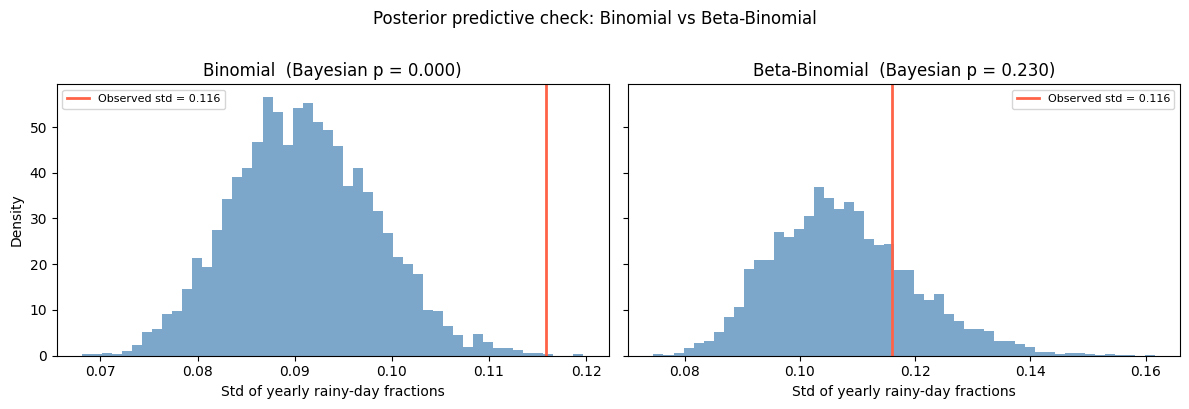

In [18]:
# Pool samples from all 4 chains
alpha_samp = np.exp(all_chains[:, :, 0].ravel())
beta_samp  = np.exp(all_chains[:, :, 1].ravel())

print("Posterior summaries (Beta-Binomial):")
print(f"  α  mean = {alpha_samp.mean():.3f},  median = {np.median(alpha_samp):.3f},"
      f"  95% CI = [{np.percentile(alpha_samp,2.5):.3f}, {np.percentile(alpha_samp,97.5):.3f}]")
print(f"  β  mean = {beta_samp.mean():.3f},  median = {np.median(beta_samp):.3f},"
      f"  95% CI = [{np.percentile(beta_samp,2.5):.3f}, {np.percentile(beta_samp,97.5):.3f}]")

p_mean_bb = alpha_samp.mean() / (alpha_samp.mean() + beta_samp.mean())
print(f"  Implied mean p  = α/(α+β) ≈ {p_mean_bb:.3f}")

# ---- Side-by-side posterior predictive check: Binomial vs Beta-Binomial ----
n_rep = 3000
idx   = rng.integers(0, len(alpha_samp), size=n_rep)

binom_stds  = np.empty(n_rep)
bb_stds     = np.empty(n_rep)

# Binomial predictive (re-use p_samp from earlier cell — draw fresh)
p_samp_fresh = rng.beta(a_post, b_post, size=n_rep)
for i in range(n_rep):
    k_b = rng.binomial(ns_year.astype(int), p_samp_fresh[i])
    binom_stds[i] = np.std(k_b / ns_year)

    ai, bi = alpha_samp[idx[i]], beta_samp[idx[i]]
    p_yr  = rng.beta(ai, bi, size=n_years)
    k_bb  = rng.binomial(ns_year.astype(int), p_yr)
    bb_stds[i] = np.std(k_bb / ns_year)

obs_std_val = obs_std

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, stds, title in zip(axes,
                            [binom_stds, bb_stds],
                            ['Binomial', 'Beta-Binomial']):
    ax.hist(stds, bins=50, density=True, color='steelblue', alpha=0.7)
    ax.axvline(obs_std_val, color='tomato', linewidth=2,
               label=f'Observed std = {obs_std_val:.3f}')
    bp = np.mean(stds >= obs_std_val)
    ax.set_title(f'{title}  (Bayesian p = {bp:.3f})')
    ax.set_xlabel('Std of yearly rainy-day fractions')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Density')
plt.suptitle('Posterior predictive check: Binomial vs Beta-Binomial', y=1.01)
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1 — Informative prior for the Beta-Binomial

Replace the HalfNormal(50) prior with a more informative HalfNormal(5) prior on both $\alpha$ and $\beta$ (i.e., expect the parameters to be small).  Re-run the sampler and compare posterior means with the weakly informative case.  Does the prior substantially change the posterior with 95 years of data?

### Exercise 2 — Effective sample size and step size

Re-run a single chain of 10 000 post-warmup samples for each of the three step sizes (0.05, 0.5, 5.0) used in the trace-plot cell.  Compute $n_{\text{eff}}$ for $\log\alpha$ in each case.  Confirm that the intermediate step size gives the highest $n_{\text{eff}}$ per unit compute.

In [10]:
# Exercise 1 — your answer here
def log_prior_informative(log_alpha, log_beta):
    pass  # replace HalfNormal(50) with HalfNormal(5)

# Exercise 2 — your answer here


In [26]:
# --- Solutions ---

# Exercise 1
def log_prior_tight(log_alpha, log_beta):
    a, b = np.exp(log_alpha), np.exp(log_beta)
    return (-0.5*(a/5)**2 - 0.5*(b/5)**2 + log_alpha + log_beta)

def log_posterior_tight(la, lb):
    return log_beta_binom_lik(la, lb) + log_prior_tight(la, lb)

chain_tight, _ = metropolis(log_posterior_tight,
                            [np.log(1.5), np.log(9.0)],
                            n_warmup2 + n_draw2, 0.5, rng)
chain_tight = chain_tight[n_warmup2:]

for j, pname in enumerate(['α', 'β']):
    orig  = np.exp(all_chains[0, :, j]).mean()
    tight = np.exp(chain_tight[:, j]).mean()
    print(f"{pname}:  weak prior mean = {orig:.3f},  tight prior mean = {tight:.3f}")

print()
print("HalfNormal(5) is noticeably informative here: with β ≈ 10, the prior")
print("places β more than 2 standard deviations from zero, pulling estimates down.")
print("A weakly informative prior (scale >> posterior values) would have little effect;")
print("HalfNormal(5) is restrictive enough to shift the posterior meaningfully.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for j, (ax, pname) in enumerate(zip(axes, ['α', 'β'])):
    weak  = np.exp(all_chains[0, :, j])
    tight = np.exp(chain_tight[:, j])
    bins  = np.linspace(min(weak.min(), tight.min()),
                        max(weak.max(), tight.max()), 50)
    ax.hist(weak,  bins=bins, density=True, alpha=0.5, color='steelblue', label='Weak prior  HalfNormal(50)')
    ax.hist(tight, bins=bins, density=True, alpha=0.5, color='tomato',    label='Tight prior HalfNormal(5)')
    ax.set_xlabel(pname)
    ax.set_ylabel('Posterior density')
    ax.set_title(f'Posterior for {pname}')
    ax.legend(fontsize=8)
plt.suptitle('Effect of prior choice on posterior (Exercise 1)', y=1.02)
plt.tight_layout()
plt.show()

print()
# Exercise 2
for b in [0.05, 0.5, 5.0]:
    samp, acc = metropolis(log_posterior,
                           [np.log(1.5), np.log(9.0)],
                           n_warmup2 + 10_000, b, rng)
    ch = samp[n_warmup2:, 0:1].T   # shape (1, 10000)
    ne = n_eff(ch)
    print(f"b = {b:5.2f},  acc = {acc:.3f},  n_eff(log α) ≈ {ne:.0f}")

α:  weak prior mean = 5.179,  tight prior mean = 1.903
β:  weak prior mean = 33.095,  tight prior mean = 11.607

HalfNormal(5) is noticeably informative here: with β ≈ 10, the prior
places β more than 2 standard deviations from zero, pulling estimates down.
A weakly informative prior (scale >> posterior values) would have little effect;
HalfNormal(5) is restrictive enough to shift the posterior meaningfully.

b =  0.05,  acc = 0.767,  n_eff(log α) ≈ 12
b =  0.50,  acc = 0.148,  n_eff(log α) ≈ 159
b =  5.00,  acc = 0.003,  n_eff(log α) ≈ 13
